In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import pytest
import matplotlib.pyplot as plt
from pymol import pyMOL

### pyMOL time series example

In [2]:
pm = pyMOL()

In [3]:
fnm = '../tests/input_data/Test_input.txt'
df = pd.read_csv(fnm, sep='\s+', skiprows=2, header=None, names=['ws', 'wd', 'Ta', 'Ts', 'time'], index_col='time', parse_dates=True)
ds = df.to_xarray()
ds.attrs = dict(zt = 13, zu = 15)

In [4]:
ds_out = pm(ds)

In [5]:
ds_out

<xarray.Dataset>
Dimensions:  (time: 14264)
Coordinates:
  * time     (time) datetime64[ns] 2000-08-29T07:30:00 ... 2000-12-22T23:00:00
Data variables:
    ws       (time) float64 4.66 4.72 4.47 4.53 4.53 ... 16.13 0.7 1.96 1.26
    wd       (time) float64 234.1 231.1 232.1 234.1 ... 305.1 289.1 277.1 249.1
    Ta       (time) float64 288.6 288.8 288.8 288.8 ... 286.1 298.0 297.0 288.8
    Ts       (time) float64 290.6 290.6 290.9 290.9 ... 281.4 279.5 279.5 279.5
    pT       (time) float64 288.8 288.9 288.9 288.9 ... 286.3 298.2 297.2 288.9
    invL     (time) float64 -0.03581 -0.03307 -0.043 ... -9.999 -9.999 -9.999
    us       (time) float64 0.1567 0.1584 0.1508 0.1528 ... 0.5862 0.0 0.0 0.0
    ths      (time) float64 -0.06513 -0.06144 -0.07249 ... -9.999 -9.999 -9.999
    z0       (time) float64 4.129e-05 4.182e-05 3.951e-05 ... 0.0 0.0 0.0
    iCalm    (time) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 1.0 1.0 1.0
    fev      (time) float64 15.0 12.0 12.0 12.0 11.0 ... 11.0 22.0 0.0 0.0 0.0
    fse      (time) float64 5.551e-17 0.0 0.0 0.0 ... 0.0 -1e-98 -1e-98 -1e-98
Attributes:
    desctiption:  Inverse Monin-Obukhov length calculated with temperature at...
    zt:           13
    zu:           15
    loc:

### AMOK calculator example

In [6]:
U = 8.0 # wind speed (m/s) measured at zu
zu = 10.0 # wind speed measurement height (m)
Tair = 19.0 # air temperature (degC) measured at zt
zt = 10.0 # air temperature measuremnt height (m)
Twater = 18.0 # sea surface temperature (degC)

In [7]:
# Using the default root finding method
pm.calcInvL(Twater, zt, Tair, zu, U)

Ws    :  8.0 m/s
Tair  : 19.0 degC
Tsea  : 18.0 degC
dTh   : 1.098 degC
1/L   : 6.771e-03 1/m
L     : 147.7 m
u*    :  0.2689 m/s
Theta*:  0.0363 degC
z0    : 9.504e-05 m
zeta0 : 6.435e-07
iCalm : 0
fev  :  10
err   : 0.000e+00


In [8]:
# Using the optional interation method
pm.calcInvL(Twater, zt, Tair, zu, U, method='iter')

Ws    :  8.0 m/s
Tair  : 19.0 degC
Tsea  : 18.0 degC
dTh   : 1.098 degC
1/L   : 6.771e-03 1/m
L     : 147.7 m
u*    :  0.2689 m/s
Theta*:  0.0363 degC
z0    : 9.504e-05 m
zeta0 : 6.435e-07
iCalm : 0
fev  :  17
err   : 1.110e-16


### pyMOL methods and AMOK comparison

In [9]:
ifnm = '../tests/input_data/Test_input.txt'
ofnm1 = '../tests/input_data/Test_output1.nc'
ofnm2 = '../tests/input_data/Test_output2.nc'

In [10]:
df = pd.read_csv(fnm, sep=r'\s+', skiprows=2, header=None,
                 names=['ws', 'wd', 'Ta', 'Ts', 'time'], index_col='time',
                 parse_dates=True)
ds = df.to_xarray()
ds.attrs = dict(zt = 13, zu = 15)

In [11]:
%%time
ds_out1 = pm(ds, method='root')

CPU times: user 2.15 s, sys: 41.3 ms, total: 2.19 s
Wall time: 2.17 s


In [12]:
%%time
ds_out2 = pm(ds, method='iter')

CPU times: user 1.75 s, sys: 1.18 ms, total: 1.75 s
Wall time: 1.77 s


#### Comparing methods

In [13]:
def compare(ds1, ds2, var='invL'):
    if 'invL' in list(ds1.keys()): ds1['1/L']=ds1['invL']
    if 'invL' in list(ds2.keys()): ds2['1/L']=ds2['invL']
    try:
        assert ds1[var].values.sum() == pytest.approx(ds2[var].values.sum())
    except AssertionError:
        print('The methods are not giving the same result!')
    else:
        print('The methods give the same result!')
    print(f'RMSD of {var}: {np.sqrt((ds1[var].values-ds2[var].values)**2).mean()}')

In [14]:
def dshist(ds, var, fa=None, bins=50, alpha=1.0, label=None):
    if fa is None:
        fig, ax = plt.subplots(figsize=(12,8))
    else:
        fig, ax = fa[0], fa[1]
    ds[var].where(ds['iCalm']==0).dropna(dim='time').plot.hist(ax=ax, bins=bins, density=True, alpha=alpha, label=label)
    if fa is None:
        return fig, ax

#### pyMOL default method is the root method

In [15]:
compare(ds_out, ds_out1)

The methods give the same result!
RMSD of invL: 0.0


#### AMOK like time series with the root finding and iteration metods should not give exactly the same results

In [16]:
compare(ds_out1, ds_out2)

The methods are not giving the same result!
RMSD of invL: 0.008729129482512948


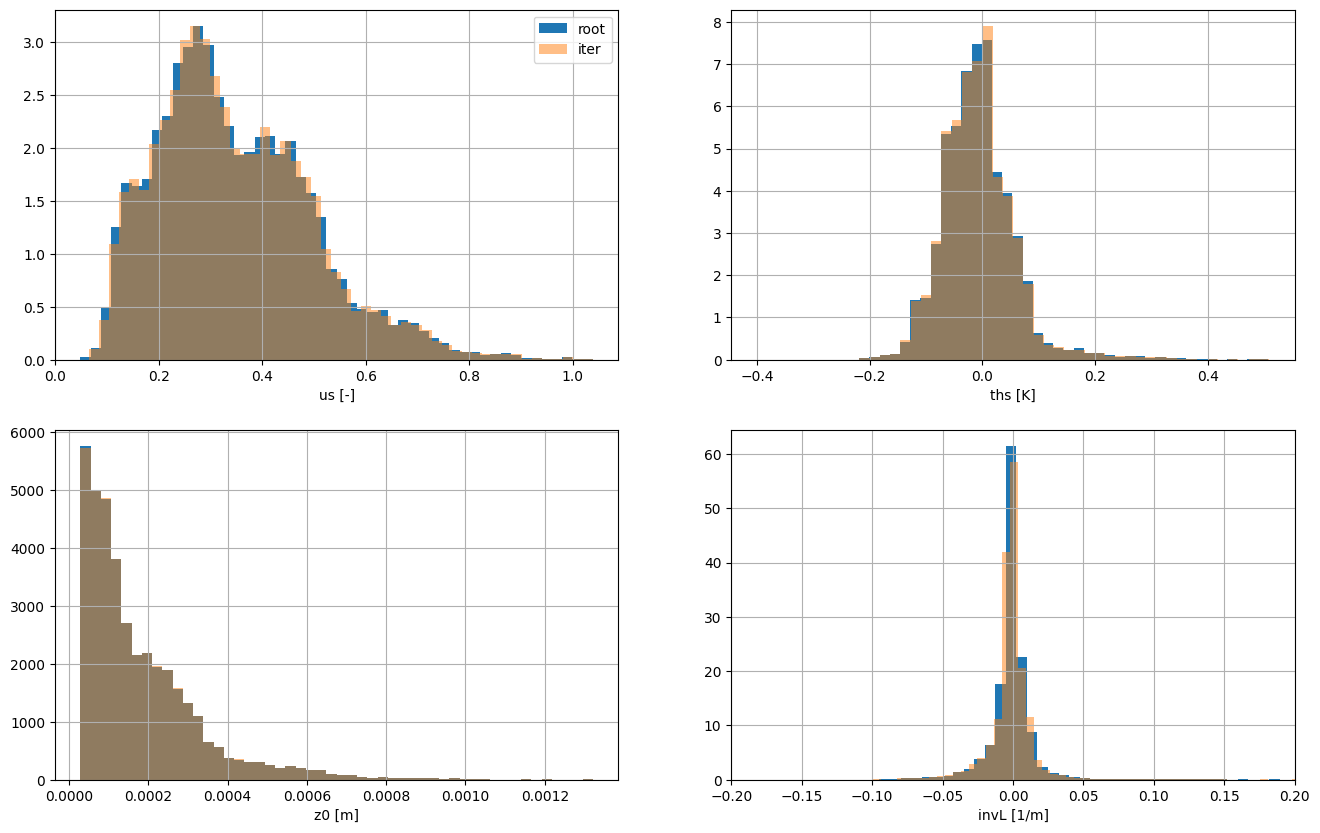

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(16,10))
var = 'us'
dshist(ds_out1, var, (fig, ax[0,0]), label='root')
dshist(ds_out2, var, (fig, ax[0,0]), alpha=0.5, label='iter')
ax[0,0].grid()
ax[0,0].legend()
var = 'ths'
dshist(ds_out1, var, (fig, ax[0,1]), label='root')
dshist(ds_out2, var, (fig, ax[0,1]), alpha=0.5, label='iter')
ax[0,1].grid()
var = 'z0'
dshist(ds_out1, var, (fig, ax[1,0]), label='root')
dshist(ds_out2, var, (fig, ax[1,0]), alpha=0.5, label='iter')
ax[1,0].grid()
var = 'invL'
dshist(ds_out1, var, (fig, ax[1,1]), bins=100, label='root')
dshist(ds_out2, var, (fig, ax[1,1]), bins=100, alpha=0.5, label='iter')
ax[1,1].grid()
ax[1,1].set_xlim((-0.2, 0.2));

#### Comparing to AMOK test result

In [18]:
ofnm3 = '../tests/input_data/AMOKtest_output.txt'

In [19]:
df_AMOK = pd.read_csv(ofnm3, sep='\s+', header=2)
time = [pd.Timestamp(str(t)).to_datetime64() for t in df_AMOK['aux']]
df_AMOK['time'] = time
df_AMOK.drop('aux', axis=1, inplace=True)
df_AMOK.set_index('time', inplace=True)
ds_AMOK = df_AMOK.to_xarray()
ds_AMOK = ds_AMOK.rename(
    {
        'u*': 'us',
        'theta*': 'ths',
        '1/L': 'invL',
    }
)

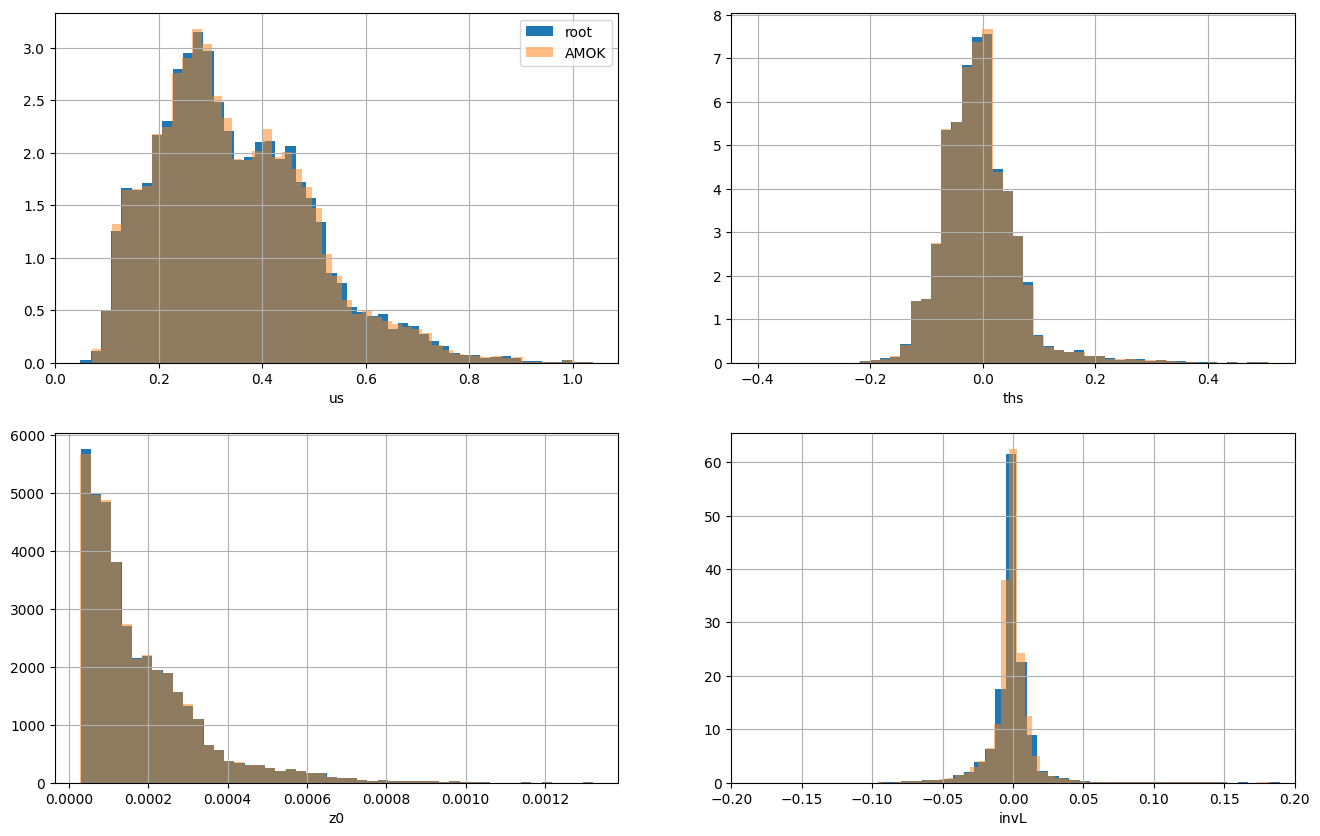

In [20]:
fig, ax = plt.subplots(2, 2, figsize=(16,10))
var = 'us'
dshist(ds_out1, var, (fig, ax[0,0]), label='root')
dshist(ds_AMOK, var, (fig, ax[0,0]), alpha=0.5, label='AMOK')
ax[0,0].grid()
ax[0,0].legend()
var = 'ths'
dshist(ds_out1, var, (fig, ax[0,1]), label='root')
dshist(ds_AMOK, var, (fig, ax[0,1]), alpha=0.5, label='AMOK')
ax[0,1].grid()
var = 'z0'
dshist(ds_out1, var, (fig, ax[1,0]), label='root')
dshist(ds_AMOK, var, (fig, ax[1,0]), alpha=0.5, label='AMOK')
ax[1,0].grid()
var = 'invL'
dshist(ds_out1, var, (fig, ax[1,1]), bins=100, label='root')
dshist(ds_AMOK, var, (fig, ax[1,1]), bins=100, alpha=0.5, label='AMOK')
ax[1,1].grid()
ax[1,1].set_xlim((-0.2, 0.2));

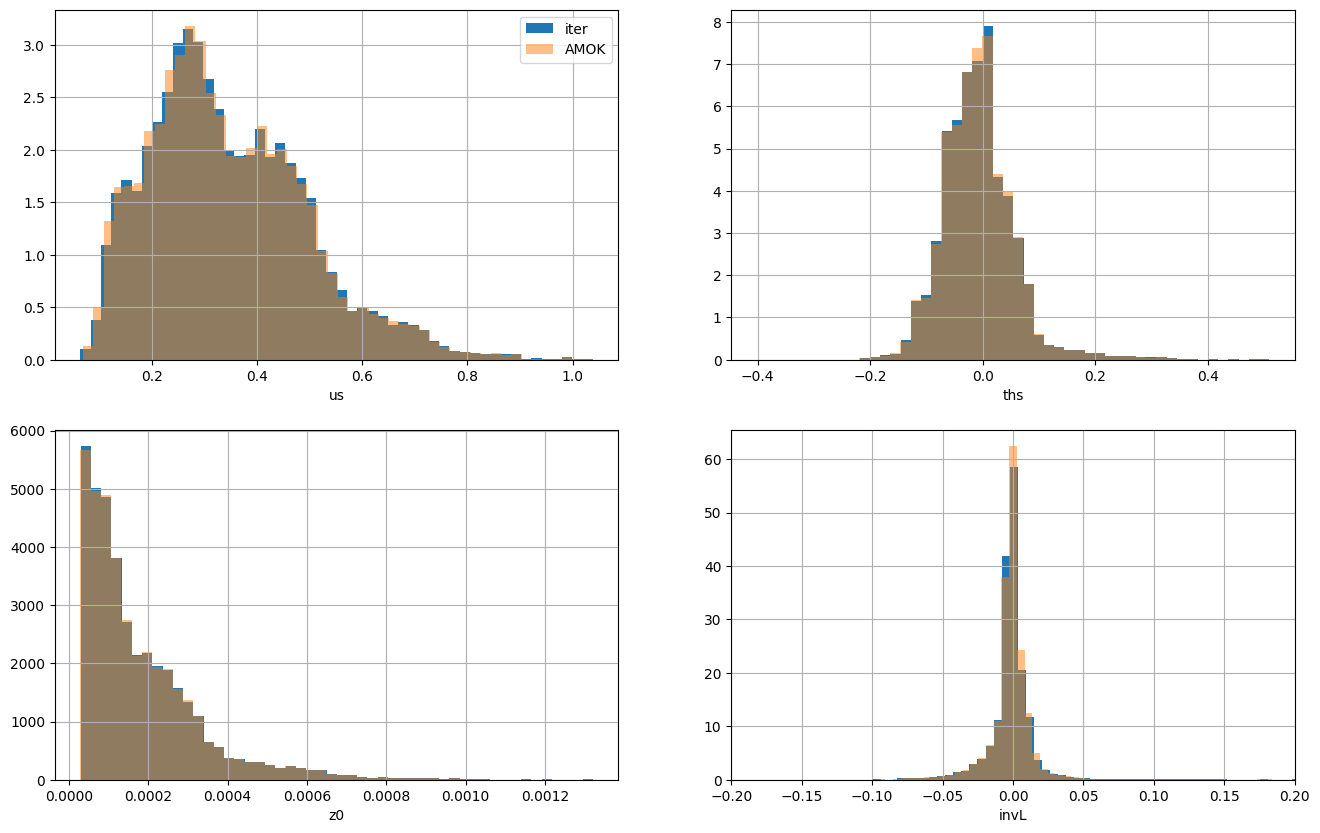

In [21]:
fig, ax = plt.subplots(2, 2, figsize=(16,10))
var = 'us'
dshist(ds_out2, var, (fig, ax[0,0]), label='iter')
dshist(ds_AMOK, var, (fig, ax[0,0]), alpha=0.5, label='AMOK')
ax[0,0].grid()
ax[0,0].legend()
var = 'ths'
dshist(ds_out2, var, (fig, ax[0,1]), label='iter')
dshist(ds_AMOK, var, (fig, ax[0,1]), alpha=0.5, label='AMOK')
ax[0,1].grid()
var = 'z0'
dshist(ds_out2, var, (fig, ax[1,0]), label='iter')
dshist(ds_AMOK, var, (fig, ax[1,0]), alpha=0.5, label='AMOK')
ax[1,0].grid()
var = 'invL'
dshist(ds_out2, var, (fig, ax[1,1]), bins=100, label='iter')
dshist(ds_AMOK, var, (fig, ax[1,1]), bins=100, alpha=0.5, label='AMOK')
ax[1,1].grid()
ax[1,1].set_xlim((-0.2, 0.2));

### Stability classification

In [22]:
stabc = { 'u': (-200,      0),
         'nu': (-500,   -200),
          'n': ( 500, np.inf),
         'ns': ( 200,    500),
          's': ( 0.0,    200)}

In [23]:
L1 = (1/ds_out1['invL'].where(ds_out1['iCalm']==0).dropna(dim='time').values)
L1[np.abs(L1)>500] = np.abs(L1[np.abs(L1)>500])
L2 = (1/ds_out2['invL'].where(ds_out2['iCalm']==0).dropna(dim='time').values)
L2[np.abs(L2)>500] = np.abs(L2[np.abs(L2)>500])
L3 = (1/ds_AMOK['invL'].where(ds_AMOK['iCalm']==0).dropna(dim='time').values)
L3[np.abs(L3)>500] = np.abs(L3[np.abs(L3)>500])

In [24]:
stab1 = pd.DataFrame(index=['Percentage of time'], columns=stabc.keys())
stab2 = pd.DataFrame(index=['Percentage of time'], columns=stabc.keys())
stab3 = pd.DataFrame(index=['Percentage of time'], columns=stabc.keys())
for key, lim in stabc.items():
    stab1[key]=np.round(100*(len(L1[np.logical_and(L1>lim[0], L1<=lim[1])])/len(L1[L1>-500])),1)
    stab2[key]=np.round(100*(len(L2[np.logical_and(L2>lim[0], L2<=lim[1])])/len(L2[L2>-500])),1)
    stab3[key]=np.round(100*(len(L3[np.logical_and(L3>lim[0], L3<=lim[1])])/len(L3[L3>-500])),1)

##### pyMOL root finding method

In [25]:
pd.concat([stab1, pd.DataFrame(stabc, index=['L lower lim.', 'L upper lim.'])])

,u,nu,n,ns,s
Percentage of time,25.8,18.4,25.6,10.2,20.0
L lower lim.,-200.0,-500.0,500.0,200.0,0.0
L upper lim.,0.0,-200.0,inf,500.0,200.0


##### pyMOL iteration method

In [26]:
pd.concat([stab2, pd.DataFrame(stabc, index=['L lower lim.', 'L upper lim.'])])

,u,nu,n,ns,s
Percentage of time,25.8,18.4,25.6,10.3,19.9
L lower lim.,-200.0,-500.0,500.0,200.0,0.0
L upper lim.,0.0,-200.0,inf,500.0,200.0


##### AMOK

In [27]:
pd.concat([stab3, pd.DataFrame(stabc, index=['L lower lim.', 'L upper lim.'])])

,u,nu,n,ns,s
Percentage of time,25.8,18.4,25.6,10.3,19.9
L lower lim.,-200.0,-500.0,500.0,200.0,0.0
L upper lim.,0.0,-200.0,inf,500.0,200.0
